In this notebook, we will be analyzing the visibility of MPs and groups, and see what insights can this offer.

In [1]:
# First, let's import the necessary libraries, and read the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('dataset.csv', parse_dates=['date'])
df = df.drop(columns=['qid', 'mp'])

In [2]:
# Second, let's aggregate values by MP

short_labels = {
    'groupe Rassemblement national': 'RN',
    'groupe Renaissance': 'Renaissance',
    'groupe La France insoumise': 'LFI',
    "groupe socialiste à l'Assemblée nationale": 'PS',
    'groupe Les Républicains (Assemblée nationale)': 'LR',
    'groupe écologiste': 'Ecologiste',
    'groupe démocrate (MoDem et indépendants)': 'MoDem',
    'Groupe Horizons et apparentés': 'Horizons',
    'groupe Libertés, indépendance, outre-mer et territoires': 'LIOT',
    'Groupe Union des droites pour la République': 'UDR',
    'groupe Gauche démocrate et républicaine': 'GDR',
    "non-inscrit à l'Assemblée nationale": 'Non-inscrit'
}

mp_stats = df.groupby(['name', 'gender', 'age', 'group'])['views'].agg(
    total_views='sum',
    mean_views='mean',
    median_views='median',
    std_views='std',
    max_views='max'
).reset_index()
mp_stats['cv'] = mp_stats['std_views'] / mp_stats['mean_views']
mp_stats['group'] = mp_stats['group'].map(short_labels)

print(mp_stats.shape)
mp_stats.head()

print("\nTop 10 most viewed MPs:")
print(mp_stats.nlargest(10, 'total_views')[['name', 'group', 'total_views']])
print("\nBottom 10 least viewed MPs:")
print(mp_stats.nsmallest(10, 'total_views')[['name', 'group', 'total_views']])

(513, 10)

Top 10 most viewed MPs:
                     name        group  total_views
314         Marine Le Pen           RN       869702
178         Gabriel Attal  Renaissance       726381
226  Jean-Philippe Tanguy           RN       656097
428       Sophia Chikirou          LFI       595181
495      Yaël Braun-Pivet  Renaissance       587300
163     François Hollande           PS       561608
318        Mathilde Panot          LFI       503581
278      Laurent Wauquiez           LR       493827
454      Sébastien Delogu          LFI       484530
293        Manuel Bompard          LFI       439047

Bottom 10 least viewed MPs:
                    name        group  total_views
500         Élie Califer           PS         3025
431         Sophie Mette        MoDem         3763
483     Vincent Thiébaut     Horizons         3776
419       Sandra Marsaud  Renaissance         3853
420  Sandrine Dogor-Such           RN         3941
34         Arnaud Simion           PS         3942
335    

Gini coefficient: 0.725

Bottom 25% of MPs → 3.1% of total views
Bottom 50% of MPs → 7.8% of total views
Bottom 75% of MPs → 16.9% of total views
Bottom 90% of MPs → 34.7% of total views
Top 10% of MPs → 65.3% of total views


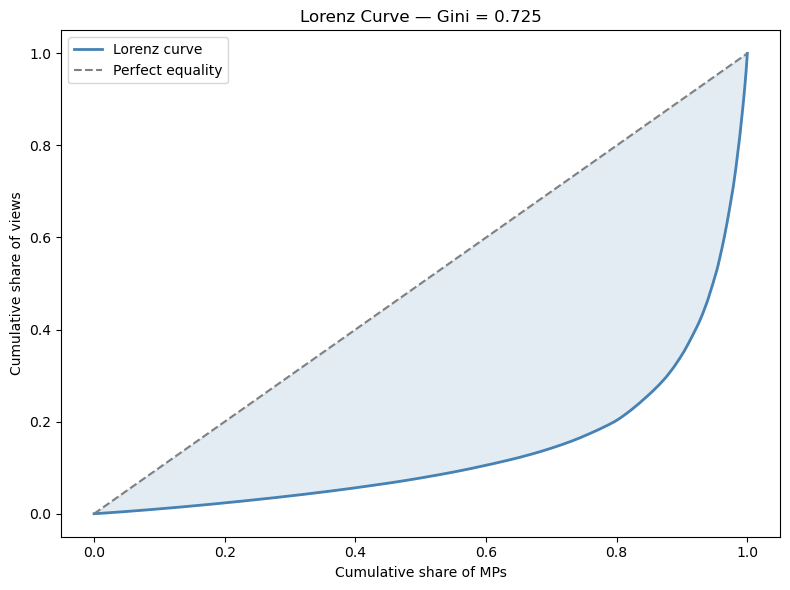

In [3]:
# Let's study visibility inequality

def gini(arr):
    arr = np.sort(arr)
    n = len(arr)
    cumsum = np.cumsum(arr)
    return (2 * np.sum((np.arange(1, n+1) * arr))) / (n * cumsum[-1]) - (n + 1) / n

total = np.sort(mp_stats['total_views'].values)
g = gini(total)

lorenz = np.cumsum(total) / total.sum()
lorenz = np.insert(lorenz, 0, 0)
x = np.linspace(0, 1, len(total) + 1)

print(f"Gini coefficient: {g:.3f}\n")
cumulative = np.cumsum(total) / total.sum()
for pct in [25, 50, 75, 90]:
    idx = int(pct / 100 * len(cumulative))
    print(f"Bottom {pct}% of MPs → {cumulative[idx]*100:.1f}% of total views")
print(f"Top 10% of MPs → {(1 - cumulative[int(0.90 * len(cumulative))])*100:.1f}% of total views")

plt.figure(figsize=(8, 6))
plt.plot(x, lorenz, color='steelblue', lw=2, label='Lorenz curve')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect equality')
plt.fill_between(x, lorenz, x, alpha=0.15, color='steelblue')
plt.title(f'Lorenz Curve — Gini = {g:.3f}')
plt.xlabel('Cumulative share of MPs')
plt.ylabel('Cumulative share of views')
plt.legend()
plt.tight_layout()
plt.show()

Wikipedia attention among French MPs is extremely concentrated (Gini = 0.725). The bottom 50% of MPs capture less than 8% of total views, while the top 10% alone account for 65%. Public attention does not distribute democratically, it follows a power law where a small elite of high-profile MPs dominates visibility entirely.

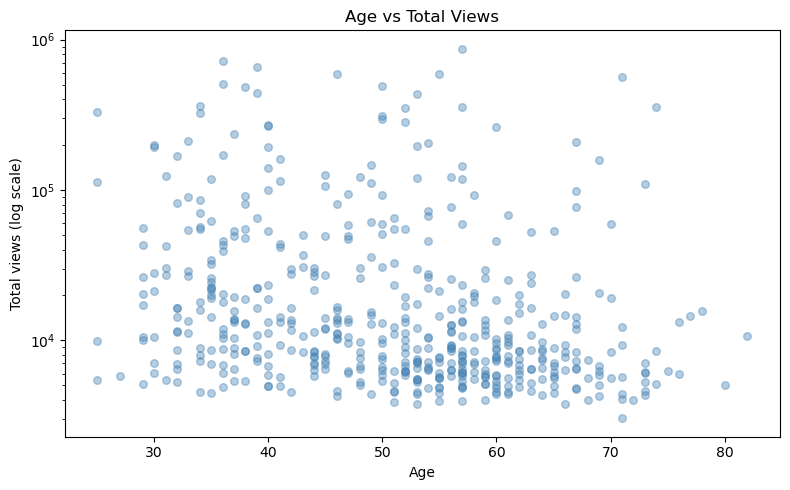

For age, Spearman correlation: -0.327, p=0.0000


In [4]:
# Now let's analyze visibility related to age alone

plt.figure(figsize=(8, 5))
plt.scatter(mp_stats['age'], mp_stats['total_views'], alpha=0.4, color='steelblue', s=30)
plt.yscale('log')
plt.xlabel('Age')
plt.ylabel('Total views (log scale)')
plt.title('Age vs Total Views')
plt.tight_layout()
plt.show()

corr, p = stats.spearmanr(mp_stats['age'], mp_stats['total_views'])
print(f"For age, Spearman correlation: {corr:.3f}, p={p:.4f}")

There is a moderate but significant negative correlation between age and Wikipedia views (Spearman = -0.327, p≈0). Older MPs tend to attract less public attention, and MPs above 70 are almost entirely invisible. However the relationship is noisy, age raises or lowers the ceiling but does not determine visibility alone, as prominent younger MPs still vary widely in attention received.

In [5]:
# Now let's analyze visibility related to gender alone

for g, color in [('M', 'steelblue'), ('F', 'tomato')]:
    sub = mp_stats[mp_stats['gender'] == g]['total_views']
    print(f"{g} — median: {sub.median():.0f}, mean: {sub.mean():.0f}, n={len(sub)}")

stat, p = stats.mannwhitneyu(
    mp_stats[mp_stats['gender'] == 'M']['total_views'],
    mp_stats[mp_stats['gender'] == 'F']['total_views'],
    alternative='two-sided'
)
print(f"\nFor gender, Mann-Whitney p={p:.4f}")

M — median: 10482, mean: 41531, n=331
F — median: 10384, mean: 45265, n=182

For gender, Mann-Whitney p=0.8668


Contrary to expectations, there is no statistically significant gender gap in Wikipedia visibility among French MPs (Mann-Whitney p=0.867). Median views are virtually identical between men and women (10,482 vs 10,384), and women's slightly higher mean is likely driven by a few high-profile outliers. Raw visibility appears gender-neutral in this dataset.

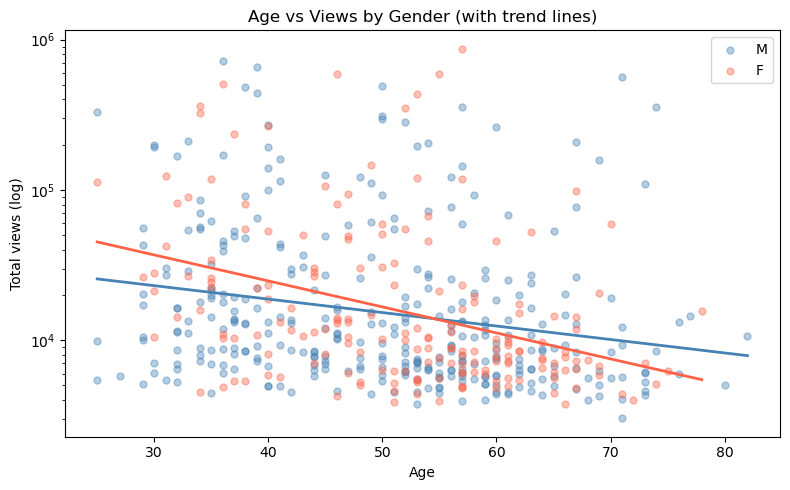

F: Spearman r=-0.415, p=0.0000
M: Spearman r=-0.285, p=0.0000


In [11]:
# Now we want to analyze how age and gender interact in this context

plt.figure(figsize=(8, 5))
for g, color in [('M', 'steelblue'), ('F', 'tomato')]:
    sub = mp_stats[mp_stats['gender'] == g]
    plt.scatter(sub['age'], sub['total_views'], alpha=0.4, s=25, color=color, label=g)
    # trend line
    z = np.polyfit(sub['age'], np.log1p(sub['total_views']), 1)
    p = np.poly1d(z)
    age_range = np.linspace(sub['age'].min(), sub['age'].max(), 100)
    plt.plot(age_range, np.expm1(p(age_range)), color=color, lw=2)
plt.yscale('log')
plt.xlabel('Age')
plt.ylabel('Total views (log)')
plt.title('Age vs Views by Gender (with trend lines)')
plt.legend()
plt.tight_layout()
plt.show()

for g, sub in mp_stats.groupby('gender'):
    corr, p = stats.spearmanr(sub['age'], sub['total_views'])
    print(f"{g}: Spearman r={corr:.3f}, p={p:.4f}")

There is no flat gender gap, but a strong age-dependent one. Young female MPs start with higher visibility than their male counterparts, but lose it faster with age (Spearman r=-0.415 vs -0.285). The two trends cross around age 50-55, after which older women are systematically less visible than older men. The gender penalty in visibility is essentially an age penalty that hits women harder.

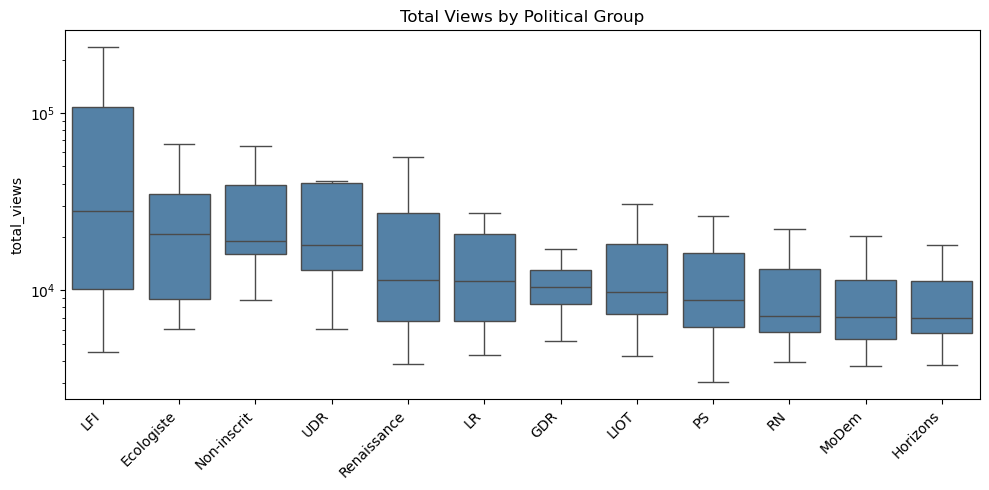

In [6]:
# Now let's analyze visibility related to group

order = mp_stats.groupby('group')['total_views'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.boxplot(data=mp_stats, x='group', y='total_views', order=order, showfliers=False, color='steelblue')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title('Total Views by Political Group')
plt.xlabel('')
plt.tight_layout()
plt.show()

      group  seat_count  view_share  seat_share  visibility_ratio
        LFI          68    0.272736    0.132554          2.057554
 Ecologiste          36    0.089925    0.070175          1.281435
        UDR          15    0.034825    0.029240          1.191009
Renaissance          79    0.173920    0.153996          1.129377
         LR          38    0.073942    0.074074          0.998212
         PS          61    0.109853    0.118908          0.923846
         RN         109    0.166393    0.212476          0.783114
Non-inscrit          11    0.014126    0.021442          0.658777
       LIOT          23    0.022426    0.044834          0.500202
      MoDem          32    0.020165    0.062378          0.323273
        GDR          14    0.007948    0.027290          0.291221
   Horizons          27    0.013742    0.052632          0.261097


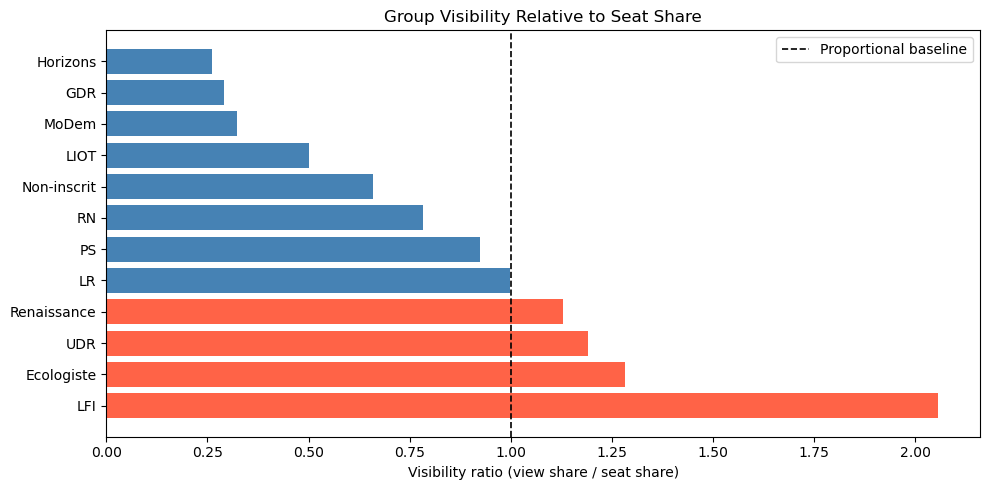

In [9]:
# Now, also in the group context, let's analyze relative to the group size

group_stats = mp_stats.groupby('group').agg(
    total_views=('total_views', 'sum'),
    seat_count=('name', 'count')
).reset_index()

group_stats['view_share'] = group_stats['total_views'] / group_stats['total_views'].sum()
group_stats['seat_share'] = group_stats['seat_count'] / group_stats['seat_count'].sum()
group_stats['visibility_ratio'] = group_stats['view_share'] / group_stats['seat_share']
group_stats = group_stats.sort_values('visibility_ratio', ascending=False)

print(group_stats[['group', 'seat_count', 'view_share', 'seat_share', 'visibility_ratio']].to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['tomato' if v > 1 else 'steelblue' for v in group_stats['visibility_ratio']]
plt.barh(group_stats['group'], group_stats['visibility_ratio'], color=colors)
plt.axvline(1, color='black', lw=1.2, linestyle='--', label='Proportional baseline')
plt.xlabel('Visibility ratio (view share / seat share)')
plt.title('Group Visibility Relative to Seat Share')
plt.legend()
plt.tight_layout()
plt.show()

LFI punches more than twice above its seat share (ratio 2.05), making it by far the most individually visible group on Wikipedia. Ecologiste and UDR also over-perform despite small seat counts. Conversely, RN which is the largest group in the Assembly, captures significantly less attention than its size would predict, confirming that its strength is collective rather than individual. Centrist satellite groups (Horizons, GDR, MoDem) are the most invisible relative to their seat share.

In [13]:
# Here, we will be analyzing the group-age interaction

print("Spearman correlation (age vs views) per group:")
for group, sub in mp_stats.groupby('group'):
    corr, p = stats.spearmanr(sub['age'], sub['total_views'])
    print(f"  {group}: r={corr:.3f}, p={p:.3f}")

Spearman correlation (age vs views) per group:
  Ecologiste: r=-0.020, p=0.908
  GDR: r=0.216, p=0.459
  Horizons: r=-0.161, p=0.423
  LFI: r=-0.438, p=0.000
  LIOT: r=-0.337, p=0.116
  LR: r=-0.301, p=0.066
  MoDem: r=-0.225, p=0.216
  Non-inscrit: r=-0.228, p=0.501
  PS: r=-0.438, p=0.000
  RN: r=-0.242, p=0.011
  Renaissance: r=-0.308, p=0.006
  UDR: r=-0.392, p=0.149


The age-visibility penalty varies significantly across groups. It is strongest in LFI and PS (r=-0.438, p≈0), where younger MPs dominate attention, consistent with these groups being driven by high-profile younger figures. Renaissance and RN also show significant negative correlations. Ecologiste and GDR show no age effect, likely due to small size and idiosyncratic visibility drivers. Overall, the age penalty is most pronounced in ideologically active, youth-engaging, media-facing groups.

In [15]:
# Here, we will be analyzing the group-gender interaction

print("Median views by group and gender:\n")
print(mp_stats.groupby(['group', 'gender'])['total_views'].median().unstack().round(0))

Median views by group and gender:

gender             F        M
group                        
Ecologiste   30013.0  13102.0
GDR           9226.0  11664.0
Horizons      9352.0   6854.0
LFI          25375.0  35870.0
LIOT         15978.0   9652.0
LR           11622.0   8917.0
MoDem         7051.0   7002.0
Non-inscrit  13685.0  19869.0
PS            9916.0   7522.0
RN            7078.0   7546.0
Renaissance  11182.0  12191.0
UDR          18785.0  16322.0


There is no universal gender direction in visibility, it flips across groups. Women outperform men most starkly in Ecologiste (2x the median views) and also in LIOT, LR, Horizons, PS and UDR. Men outperform women in LFI and marginally in GDR, RN and Renaissance. MoDem is essentially gender-neutral. This group-level variation explains why the overall gender gap test found no significant difference, the effects cancel each other out in aggregate.

/tmp/ipykernel_427904/1502539702.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10 = mp_stats.groupby('group').apply(lambda x: top_pct_share(x, 0.10)).reset_index()
/tmp/ipykernel_427904/1502539702.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_ginis = mp_stats.groupby('group').apply(lambda x: gini(x['total_views'].values)).reset_index()


Concentration of views within group (top 10%):
      group  top10_share
         RN    73.139778
         PS    71.891288
         LR    70.990290
Renaissance    66.361764
 Ecologiste    62.271902
        UDR    56.252098
       LIOT    53.806993
      MoDem    49.110258
        LFI    48.561898
Non-inscrit    40.049460
   Horizons    33.534139
        GDR    30.850985

Gini by group:
      group     gini
         RN 0.753971
Renaissance 0.738409
         PS 0.738079
         LR 0.731264
 Ecologiste 0.667272
        LFI 0.656400
        UDR 0.609994
       LIOT 0.536466
      MoDem 0.496017
   Horizons 0.382276
Non-inscrit 0.358343
        GDR 0.276652


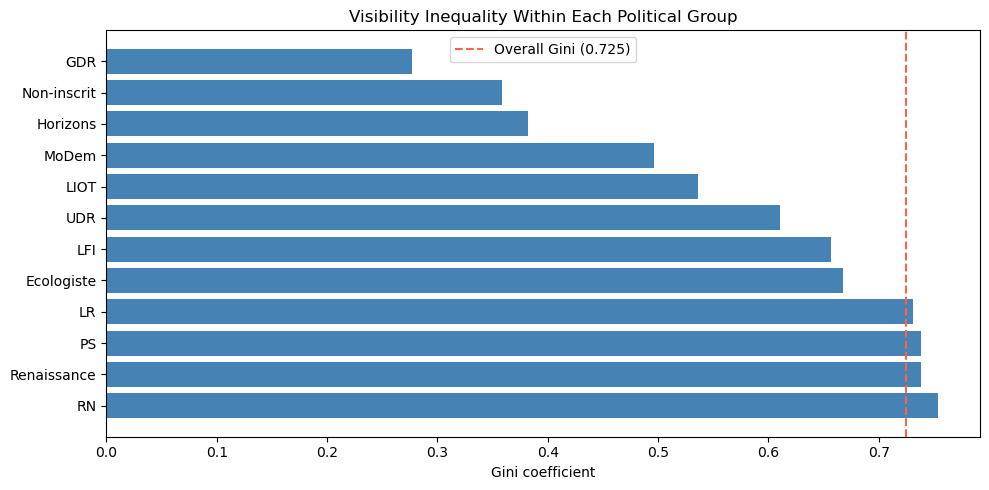

In [18]:
# Now, we will study the visibility inequality within the groups themselves

def top_pct_share(group_df, pct=0.10):
    n = max(1, int(np.ceil(len(group_df) * pct)))
    top = group_df.nlargest(n, 'total_views')['total_views'].sum()
    return top / group_df['total_views'].sum() * 100

top10 = mp_stats.groupby('group').apply(lambda x: top_pct_share(x, 0.10)).reset_index()
top10.columns = ['group', 'top10_share']
top10 = top10.sort_values('top10_share', ascending=False)
print("Concentration of views within group (top 10%):")
print(top10.to_string(index=False))

group_ginis = mp_stats.groupby('group').apply(lambda x: gini(x['total_views'].values)).reset_index()
group_ginis.columns = ['group', 'gini']
group_ginis = group_ginis.sort_values('gini', ascending=False)
print("\nGini by group:")
print(group_ginis.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(group_ginis['group'], group_ginis['gini'], color='steelblue')
plt.axvline(0.725, color='tomato', linestyle='--', label='Overall Gini (0.725)')
plt.xlabel('Gini coefficient')
plt.title('Visibility Inequality Within Each Political Group')
plt.legend()
plt.tight_layout()
plt.show()

RN is the most internally unequal group (Gini=0.754), with 73% of its views concentrated in just 10% of its MPs, the rest are virtually invisible. PS and LR follow a similar pattern, reflecting old parties where a few historic figures dominate. LFI stands out as the exception: despite being the highest-visibility group overall, it distributes attention more equally internally (Gini=0.656, top 10% capturing 49%). GDR is the most equal group but for the wrong reason, everyone is equally ignored. The contrast between RN and LFI is the sharpest finding: LFI punches above its weight and shares it, RN underperforms and concentrates it.

In [20]:
# Now, let's tackle overperformance by group

group_medians = mp_stats.groupby('group')['total_views'].median()
mp_stats['group_median'] = mp_stats['group'].map(group_medians)
mp_stats['overperform_ratio_group'] = mp_stats['total_views'] / mp_stats['group_median']
top_overperformers_group = mp_stats.nlargest(10, 'overperform_ratio_group')[['name', 'group', 'gender', 'age', 'total_views', 'overperform_ratio_group']]
print("Top 10 overperformers relative to their group:")
print(top_overperformers_group.to_string(index=False))

Top 10 overperformers relative to their group:
                name       group gender  age  total_views  overperform_ratio_group
       Marine Le Pen          RN      F   57       869702               121.195931
Jean-Philippe Tanguy          RN      M   39       656097                91.429348
       Gabriel Attal Renaissance      M   36       726381                63.600473
   François Hollande          PS      M   71       561608                63.394063
    Yaël Braun-Pivet Renaissance      F   55       587300                51.422818
    Laurent Wauquiez          LR      M   50       493827                43.651286
       Olivier Faure          PS      M   57       353840                39.941303
     Sébastien Chenu          RN      M   52       281374                39.210424
        Julien Odoul          RN      M   40       270750                37.729933
       Boris Vallaud          PS      M   50       310958                35.100801


Marine Le Pen stands alone at 121x her group's median, by far the biggest outlier in the assembly, likely driven by her status as former presidential candidate and 2027 frontrunner. RN places 4 MPs in the top 10 despite being the most internally unequal group, confirming a stark two-tier structure. PS is the surprise with 3 overperformers, suggesting a handful of strong individual figures carry the entire group. LFI's absence confirms its visibility is broadly distributed, not star-driven.

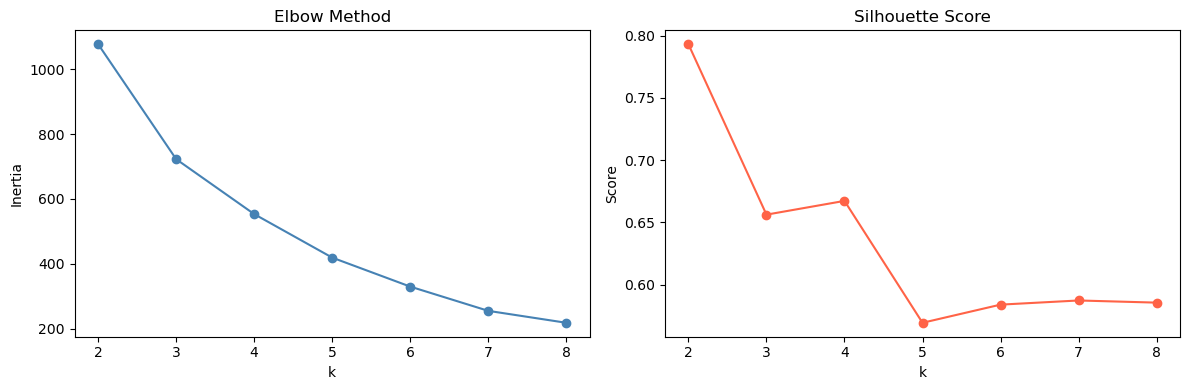

Silhouette scores:
  k=2: 0.793
  k=3: 0.656
  k=4: 0.667
  k=5: 0.569
  k=6: 0.584
  k=7: 0.587
  k=8: 0.586


In [21]:
# Now, we would like to cluster MPs based on visibility, let's say giving them an attention indicator

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

features = mp_stats[['mean_views', 'cv', 'max_views', 'median_views']].copy().fillna(0)
scaler = StandardScaler()
X = scaler.fit_transform(features)

inertias, silhouettes = [], []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K, inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(K, silhouettes, 'o-', color='tomato')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

print("Silhouette scores:")
for k, s in zip(K, silhouettes):
    print(f"  k={k}: {s:.3f}")

K=2 is obviously the cleanest split but won't be very informative. So, let's do k=4 which is the second-best.

In [22]:
# Perform the clustering with k=4

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
mp_stats['cluster'] = km_final.fit_predict(X)

# Cluster profiles
print("Cluster profiles:")
print(mp_stats.groupby('cluster')[['mean_views', 'median_views', 'max_views', 'cv']].mean().round(1))

print("\nCluster sizes:")
print(mp_stats['cluster'].value_counts().sort_index())

Cluster profiles:
         mean_views  median_views  max_views   cv
cluster                                          
0              47.2          32.1      716.7  1.1
1             959.6         588.5    12605.3  1.3
2             158.8          60.7     7886.5  3.6
3            1903.1        1094.5    49283.5  2.1

Cluster sizes:
cluster
0    425
1     24
2     60
3      4
Name: count, dtype: int64


Four distinct attention profiles emerge among French MPs. 
Cluster 0: The vast majority (425, 83%) are essentially invisible on Wikipedia with negligible daily traffic. 
Cluster 1: A spiky middle tier (60 MPs) gets ignored most days but occasionally bursts into attention, likely tied to specific events. 
Cluster 2: A visible steady tier (24 MPs) maintains consistent recognizable traffic year-round. 
Cluster 3: At the top, only 4 MPs qualify as true stars with dramatically higher views. 

In [29]:
# Analysis of the four clusters

for c in [3, 2, 1, 0]:
    sub = mp_stats[mp_stats['cluster'] == c]
    print(f"\n- CLUSTER {c} — {len(sub)} MPs")
    print(f"\nAge — mean: {sub['age'].mean():.1f}, median: {sub['age'].median():.1f}")
    print(f"Gender — {sub['gender'].value_counts().to_dict()}")
    print(f"Group composition:\n{sub['group'].value_counts().to_string()}")
    if c == 3:
        print(f"\nMPs: {', '.join(sub['name'].tolist())}")


- CLUSTER 3 — 4 MPs

Age — mean: 48.5, median: 50.5
Gender — {'F': 3, 'M': 1}
Group composition:
group
Renaissance    2
RN             1
LFI            1

MPs: Gabriel Attal, Marine Le Pen, Sophia Chikirou, Yaël Braun-Pivet

- CLUSTER 2 — 60 MPs

Age — mean: 47.3, median: 47.0
Gender — {'M': 34, 'F': 26}
Group composition:
group
LFI            9
PS             9
RN             8
Renaissance    7
LIOT           5
MoDem          5
Ecologiste     5
LR             4
Non-inscrit    4
UDR            3
Horizons       1

- CLUSTER 1 — 24 MPs

Age — mean: 46.5, median: 45.0
Gender — {'M': 17, 'F': 7}
Group composition:
group
LFI            10
PS              3
Ecologiste      3
RN              3
LR              2
Renaissance     2
UDR             1

- CLUSTER 0 — 425 MPs

Age — mean: 51.4, median: 53.0
Gender — {'M': 279, 'F': 146}
Group composition:
group
RN             97
Renaissance    68
PS             49
LFI            48
LR             32
Ecologiste     28
MoDem          27
Horizons     

- Stars (4 MPs): A cross-party elite of household names, remarkably 3 out of 4 are women, suggesting that women who break through the visibility ceiling do so decisively.
- Spiky (60 MPs): The most diverse and youngest cluster, MPs who surface occasionally due to controversy or news but have no sustained presence.
- Visible (24 MPs): LFI dominates this tier (10/24), confirming it produces the most consistently visible MPs beyond the star level, a structural party effect, not individual luck.
- Invisible (425 MPs): 83% of the assembly, oldest, and RN deposits 97 MPs here, the most of any group, cementing its rank-and-file anonymity on Wikipedia.